In [9]:
import zipfile
import os

zip_path = r'C:\Users\HP\Downloads\archive.zip'
os.chdir(r'C:\Users\HP\Downloads')

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall('.')
    print(z.namelist())

['WA_Fn-UseC_-HR-Employee-Attrition.csv']


In [17]:
!pip install pandas

In [19]:
import pandas as pd

df = pd.read_csv(r'C:\Users\HP\Downloads\WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [20]:
# كم موظف ترك وكم بقي
print(df['Attrition'].value_counts())
print("\n")
print(df['Attrition'].value_counts(normalize=True) * 100)

Attrition
No     1233
Yes     237
Name: count, dtype: int64


Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


In [26]:
!pip install matplotlib seaborn

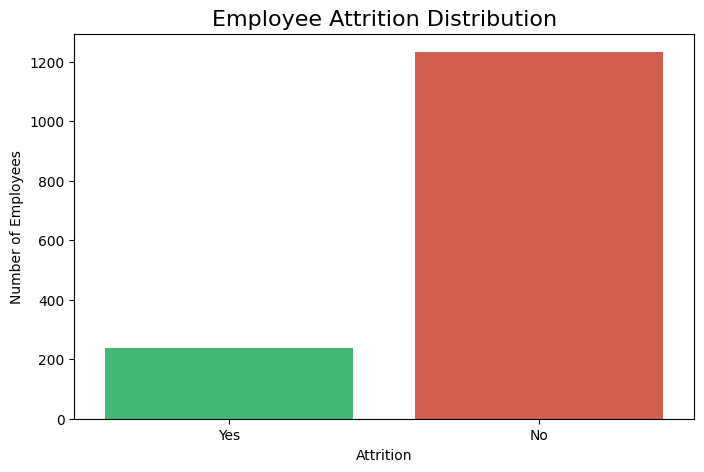

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Attrition', hue='Attrition', palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title('Employee Attrition Distribution', fontsize=16)
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')
plt.show()

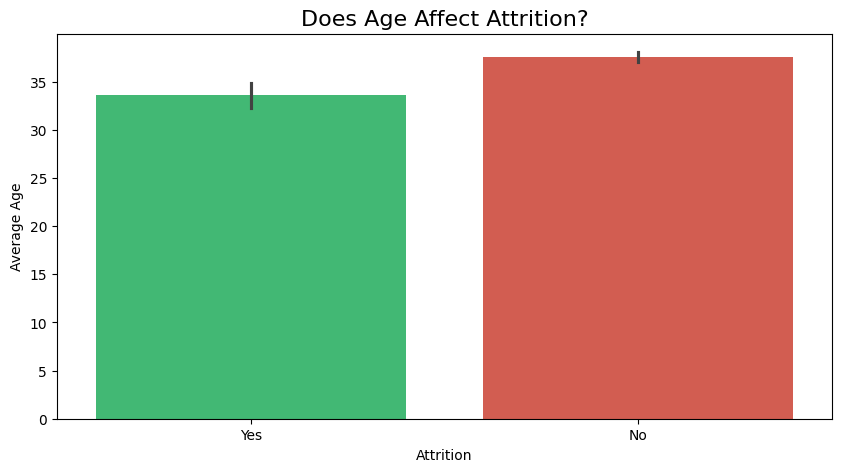

In [31]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='Attrition', y='Age', 
            hue='Attrition', palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title('Does Age Affect Attrition?', fontsize=16)
plt.xlabel('Attrition')
plt.ylabel('Average Age')
plt.show()

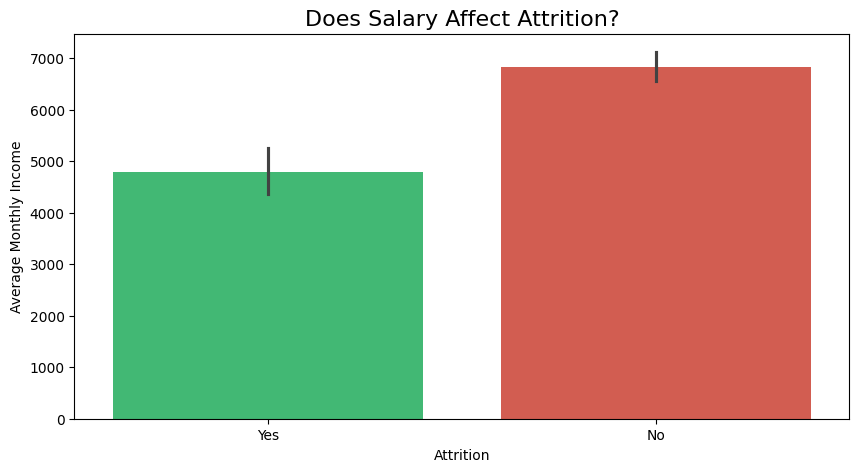

In [32]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='Attrition', y='MonthlyIncome',
            hue='Attrition', palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title('Does Salary Affect Attrition?', fontsize=16)
plt.xlabel('Attrition')
plt.ylabel('Average Monthly Income')
plt.show()

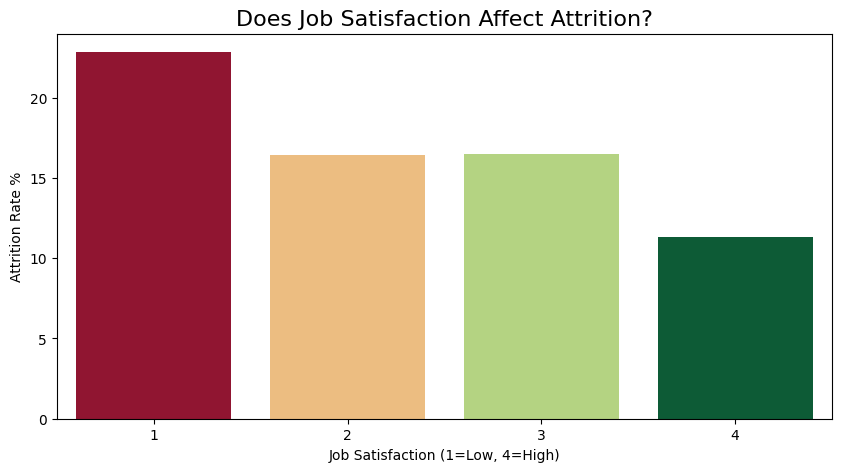

In [35]:
satisfaction_attrition = df.groupby('JobSatisfaction')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
satisfaction_attrition.columns = ['JobSatisfaction', 'AttritionRate']

plt.figure(figsize=(10, 5))
sns.barplot(data=satisfaction_attrition, x='JobSatisfaction', y='AttritionRate',
            hue='JobSatisfaction', palette='RdYlGn', legend=False)
plt.title('Does Job Satisfaction Affect Attrition?', fontsize=16)
plt.xlabel('Job Satisfaction (1=Low, 4=High)')
plt.ylabel('Attrition Rate %')
plt.show()

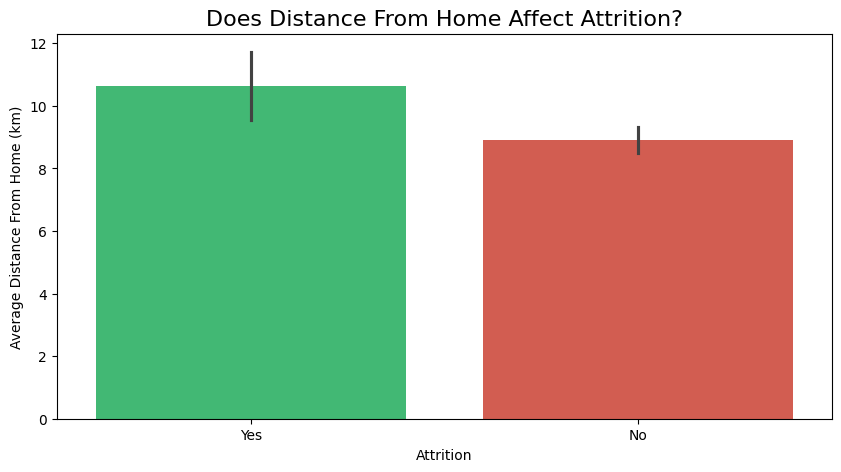

In [36]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='Attrition', y='DistanceFromHome',
            hue='Attrition', palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title('Does Distance From Home Affect Attrition?', fontsize=16)
plt.xlabel('Attrition')
plt.ylabel('Average Distance From Home (km)')
plt.show()

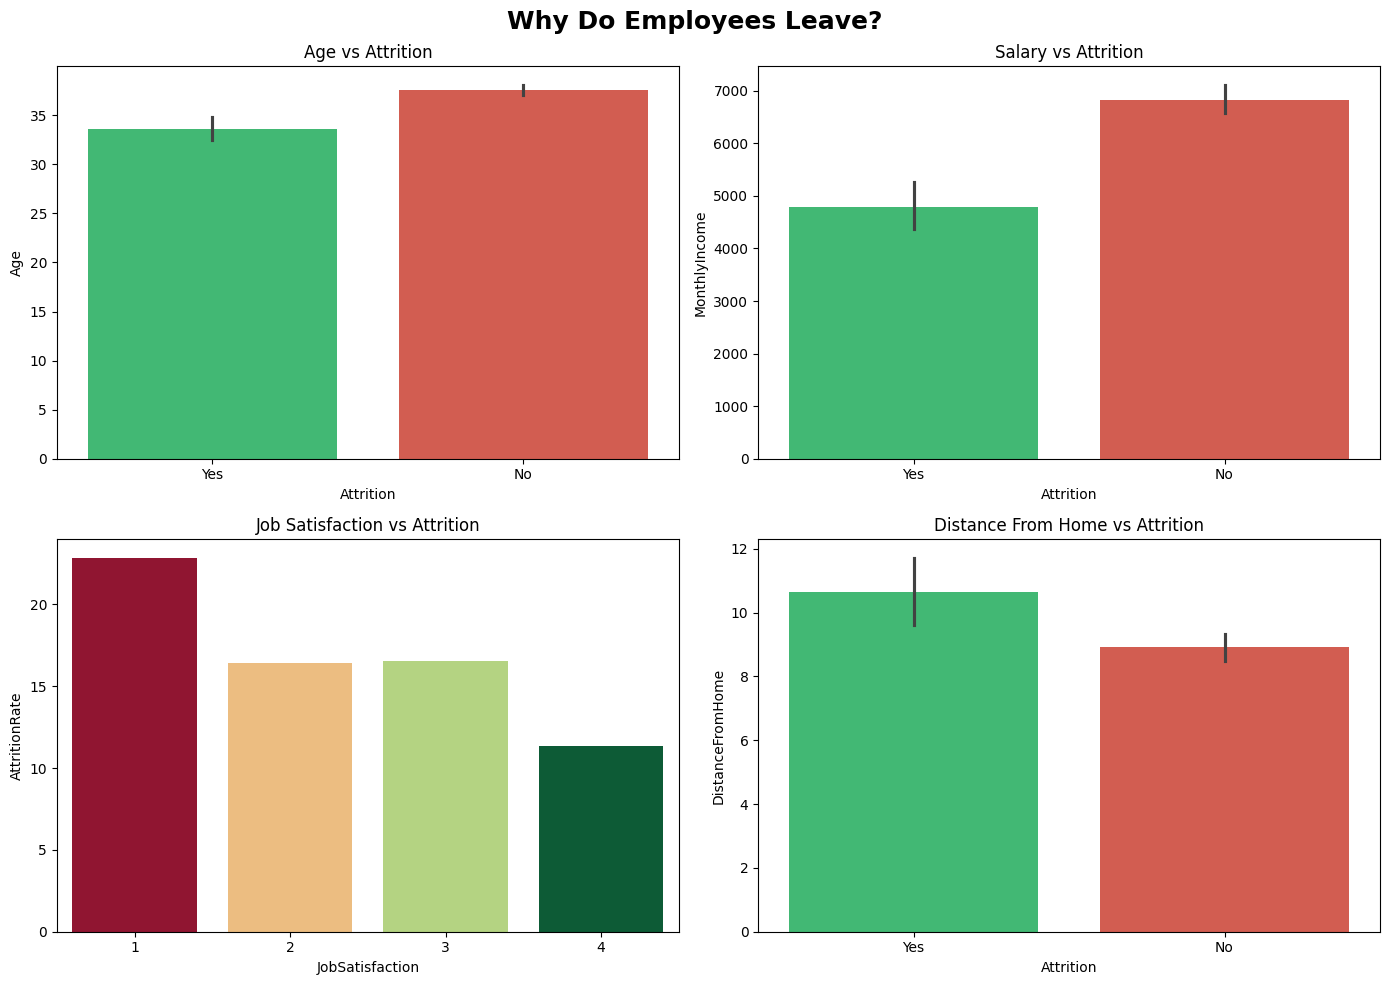

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Why Do Employees Leave?', fontsize=18, fontweight='bold')

sns.barplot(data=df, x='Attrition', y='Age',
            hue='Attrition', palette=['#2ecc71', '#e74c3c'], 
            legend=False, ax=axes[0,0])
axes[0,0].set_title('Age vs Attrition')

sns.barplot(data=df, x='Attrition', y='MonthlyIncome',
            hue='Attrition', palette=['#2ecc71', '#e74c3c'], 
            legend=False, ax=axes[0,1])
axes[0,1].set_title('Salary vs Attrition')

sns.barplot(data=satisfaction_attrition, x='JobSatisfaction', y='AttritionRate',
            hue='JobSatisfaction', palette='RdYlGn', legend=False, ax=axes[1,0])
axes[1,0].set_title('Job Satisfaction vs Attrition')

sns.barplot(data=df, x='Attrition', y='DistanceFromHome',
            hue='Attrition', palette=['#2ecc71', '#e74c3c'], 
            legend=False, ax=axes[1,1])
axes[1,1].set_title('Distance From Home vs Attrition')

plt.tight_layout()
plt.savefig('attrition_analysis.png', dpi=150, bbox_inches='tight')
plt.show()